In [1]:
import pandas as pd


In [2]:
df=pd.read_csv('spam.csv', encoding='latin-1')

In [3]:
df=df[['v1','v2']]

In [4]:
df['v2'][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [5]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 22.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=1a7cb0f9cda00d8827ae028dc35e96b4c81128b4f354a100f7fd232aad9d9cc8
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [6]:
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException

def is_english(text):
    try:
        return detect(text) == 'en'
    except LangDetectException:
        return False

df_english = df[df['v2'].apply(is_english)]
display(df_english.head())

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...


In [7]:
df.shape

(5572, 2)

In [8]:
df_english.shape


(5044, 2)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

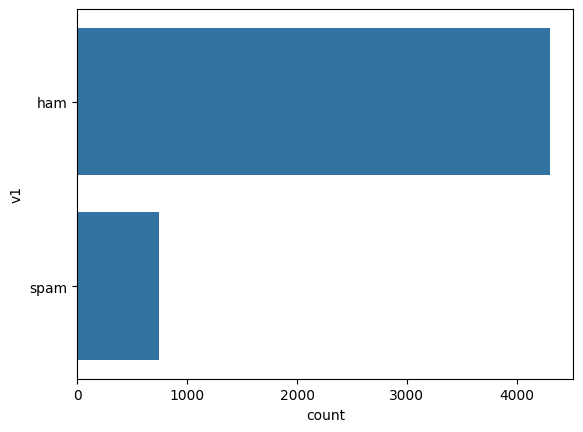

In [10]:
sns.countplot(df_english['v1'])
plt.show()

In [11]:
df_english['v1'].value_counts()

,count
v1,
ham,4302
spam,742


In [13]:
df_english.duplicated().sum()

np.int64(332)

In [12]:
from sklearn.preprocessing import LabelEncoder
la=LabelEncoder()
df_english['v1']=la.fit_transform(df_english['v1'])

/tmp/ipython-input-3298475344.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_english['v1']=la.fit_transform(df_english['v1'])


In [14]:
df_english.drop_duplicates(inplace=True)

/tmp/ipython-input-1641622232.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_english.drop_duplicates(inplace=True)


In [15]:
x=df_english['v2']
y=df_english['v1']

In [16]:
x

,v2
0,"Go until jurong point, crazy.. Available only ..."
2,Free entry in 2 a wkly comp to win FA Cup fina...
3,U dun say so early hor... U c already then say...
4,"Nah I don't think he goes to usf, he lives aro..."
5,FreeMsg Hey there darling it's been 3 week's n...
...,...
5567,This is the 2nd time we have tried 2 contact u...
5568,Will Ì_ b going to esplanade fr home?
5569,"Pity, * was in mood for that. So...any other s..."
5570,The guy did some bitching but I acted like i'd...


In [40]:
y[0]

np.int64(0)

In [17]:
x.str.lower()

,v2
0,"go until jurong point, crazy.. available only ..."
2,free entry in 2 a wkly comp to win fa cup fina...
3,u dun say so early hor... u c already then say...
4,"nah i don't think he goes to usf, he lives aro..."
5,freemsg hey there darling it's been 3 week's n...
...,...
5567,this is the 2nd time we have tried 2 contact u...
5568,will ì_ b going to esplanade fr home?
5569,"pity, * was in mood for that. so...any other s..."
5570,the guy did some bitching but i acted like i'd...


In [19]:
import nltk
nltk.download('stopwords')
import re
from nltk.corpus import stopwords

sw_list = stopwords.words('english')

# Convert to lowercase
x = x.str.lower()

# Remove special symbols and punctuation
x = x.apply(lambda y: re.sub(r'[^a-zA-Z0-9\s]', '', y))

# Remove stopwords
x = x.apply(lambda y: [item for item in y.split() if item not in sw_list]).apply(lambda y:" ".join(y))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [20]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [21]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense


In [22]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,df_english['v1'],test_size=0.2,random_state=42)

In [23]:
#before overshaping
y_train.value_counts()

,count
v1,
0,3249
1,520


In [24]:
x_train

,v2
2490,dun b sad dun thk abt already concentrate ur p...
1846,engalnd telly decided wont let watch mia ellio...
5079,keep ur problems ur heart
678,cause im freaky lol
3960,dad back ph
...,...
5224,oh fuck juswoke bed boatin docks slept wid 25 ...
527,yes pretty lady like single
3602,im sure checking happening around area
4416,says hes quitting least5times day wudnt take m...


In [25]:
toki=Tokenizer()
toki.fit_on_texts(x_train)

In [26]:
toki.word_index

{'u': 1,
 'call': 2,
 'im': 3,
 '2': 4,
 'get': 5,
 'ur': 6,
 'dont': 7,
 '4': 8,
 'know': 9,
 'free': 10,
 'go': 11,
 'like': 12,
 'come': 13,
 'ok': 14,
 'got': 15,
 'good': 16,
 'ill': 17,
 'ltgt': 18,
 'want': 19,
 'time': 20,
 'day': 21,
 'text': 22,
 'love': 23,
 'need': 24,
 'one': 25,
 'home': 26,
 'see': 27,
 'send': 28,
 'going': 29,
 'txt': 30,
 'still': 31,
 'back': 32,
 'lor': 33,
 'stop': 34,
 'think': 35,
 'well': 36,
 'new': 37,
 'n': 38,
 'reply': 39,
 'tell': 40,
 'take': 41,
 'r': 42,
 'sorry': 43,
 'today': 44,
 'mobile': 45,
 'please': 46,
 'cant': 47,
 'much': 48,
 'phone': 49,
 'great': 50,
 'da': 51,
 'hi': 52,
 'hey': 53,
 'give': 54,
 'oh': 55,
 'make': 56,
 'night': 57,
 'thats': 58,
 'already': 59,
 'week': 60,
 'hope': 61,
 'claim': 62,
 'way': 63,
 'really': 64,
 'happy': 65,
 'later': 66,
 'number': 67,
 'yeah': 68,
 'dear': 69,
 'wat': 70,
 'work': 71,
 'pls': 72,
 'ask': 73,
 'say': 74,
 'said': 75,
 'c': 76,
 'tomorrow': 77,
 'prize': 78,
 'thanks': 79

In [27]:
max_len=len(toki.word_index)
max_len

7793

In [28]:
x_train=toki.texts_to_sequences(x_train)
x_test=toki.texts_to_sequences(x_test)


In [29]:
from keras.utils import pad_sequences
x_train=pad_sequences(x_train,maxlen=max_len,padding='post')
x_test=pad_sequences(x_test,maxlen=max_len,padding='post')
x_train[0]

array([130, 107, 534, ...,   0,   0,   0], dtype=int32)

In [30]:
display(y_train.value_counts())

,count
v1,
0,3249
1,520


In [31]:
model=Sequential()
model.add(Embedding(max_len,64,input_length=max_len))
model.add(LSTM(128))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=10,batch_size=32,validation_data=(x_test,y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 36s 246ms/step - accuracy: 0.8404 - loss: 0.4346 - val_accuracy: 0.8632 - val_loss: 0.3993
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 28s 239ms/step - accuracy: 0.8580 - loss: 0.4099 - val_accuracy: 0.8632 - val_loss: 0.4035
Epoch 3/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 29s 244ms/step - accuracy: 0.8579 - loss: 0.4129 - val_accuracy: 0.8632 - val_loss: 0.3999
Epoch 4/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 37s 316ms/step - accuracy: 0.8545 - loss: 0.4172 - val_accuracy: 0.8632 - val_loss: 0.4004
Epoch 5/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 41s 346ms/step - accuracy: 0.8575 - loss: 0.4120 - val_accuracy: 0.8632 - val_loss: 0.4063
Epoch 6/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 31s 266ms/step - accuracy: 0.8633 - loss: 0.4009 - val_accuracy: 0.8632 - val_loss: 0.4003
Epoch 7/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 29s 243ms/step - accuracy: 0.8543 - loss: 0.4177 - val_accuracy: 0.8632 - val_loss: 0.3992
Epoch 8/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 32s 271ms/step - accuracy: 0.8692 - loss: 0

In [32]:
y_pred=model.predict(x_test)

30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step


In [33]:
from sklearn.metrics import accuracy_score
y_pred = (model.predict(x_test) > 0.5).astype("int32")
print(accuracy_score(y_test,y_pred))

30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step
0.8632025450689289


In [41]:
import numpy as np
import re
from keras.utils import pad_sequences

text_raw = df['v2'][0]

# Preprocess the new text exactly as the training data was preprocessed
text_processed = text_raw.lower()
text_processed = re.sub(r'[^a-zA-Z0-9\s]', '', text_processed)
text_words = [item for item in text_processed.split() if item not in sw_list]
text_final = " ".join(text_words)

# Tokenize the preprocessed text
seq = toki.texts_to_sequences([text_final])

# Pad the sequence
padded_seq = pad_sequences(seq, maxlen=max_len, padding='post')

pred = model.predict(padded_seq)
if pred > 0.5:
    print('not_spam')
else:
    print('spam')



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step
spam
